## Install dependencies

In [2]:
!pip install -q transformers peft datasets evaluate accelerate wandb bitsandbytes matplotlib scikit-learn

# !pip install -q flash-attn --no-build-isolation

##  Imports

In [3]:
from __future__ import annotations

import os
import time
import warnings
from dataclasses import dataclass, field
from typing import Callable
import gc
import subprocess
import evaluate as hf_evaluate
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset, Dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    EarlyStoppingCallback,
)
 
warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)

In [4]:
# Detect backend
if torch.cuda.is_available():
    DEVICE   = "cuda"
    USE_BF16 = False
    USE_FP16 = True
elif torch.backends.mps.is_available():
    DEVICE   = "mps"
    USE_BF16 = False
    USE_FP16 = False
else:
    # TPU (XLA) or CPU — HuggingFace Trainer handles XLA automatically
    DEVICE   = "cpu"   # Trainer overrides this for TPU via XLA
    USE_BF16 = True    # bfloat16 is native on TPU
    USE_FP16 = False

print(f"Backend: {DEVICE} | bf16={USE_BF16} | fp16={USE_FP16}")

Backend: cuda | bf16=False | fp16=True


In [5]:
def check_hardware():
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.free,memory.total,name",
            "--format=csv,noheader,nounits"],
            capture_output=True, text=True
        )
        if result.returncode == 0 and result.stdout.strip():
            free, total, name = result.stdout.strip().split(", ")
            print(f"GPU: {name}")
            print(f"  Free: {int(free)/1024:.1f} GB / {int(total)/1024:.1f} GB")
    except:
        # TPU or CPU — nvidia-smi not available
        try:
            import torch_xla.core.xla_model as xm
            print(f"TPU: {xm.xla_device()}")
            print(f"  Devices: {xm.get_xla_supported_devices()}")
        except ImportError:
            print("Backend: CPU (no GPU or TPU detected)")

check_hardware()

GPU: NVIDIA A10
  Free: 22.1 GB / 22.5 GB


In [6]:
import json
import os
from pathlib import Path

# ── Logging config ────────────────────────────────────────────────────────────
USE_WANDB   = True
WANDB_PROJECT = "thesis-preliminary"
WANDB_ENTITY = "ilham-abdillah-alhamdi-universitas-indonesia"
SAVE_JSON   = True
JSON_DIR    = Path("./preliminary_results")
JSON_DIR.mkdir(exist_ok=True)

if USE_WANDB:
    import wandb

## 2. Configuration

In [8]:
@dataclass
class LoRAConfig:
    r: int               = 8
    lora_alpha: int      = 16
    lora_dropout: float  = 0.05
    target_modules: list[str] = field(
        default_factory=lambda: ["Wqkv", "attn.Wo", "mlp.Wi", "mlp.Wo"]
    )
    bias: str = "none"
 
 
@dataclass
class TaskConfig:
    name: str
    hf_path: str
    hf_subset: str | None
    text_fields: list[str]
    label_field: str
    num_labels: int
    metric_name: str
    metric_key: str
    choices_field: str | None = None  # set to "choices" for MMLU-style datasets
    train_split: str     = "train"
    val_split: str       = "validation"
    model_name: str      = "answerdotai/ModernBERT-base"
    lora: LoRAConfig     = field(default_factory=LoRAConfig)
    learning_rate: float = 5e-4
    batch_size: int      = 64
    num_epochs: int      = 15    # upper limit; plateau detection stops earlier
    eval_fraction: float = 0.25
    max_seq_len: int     = 512
    weight_decay: float  = 0.01

 ## 3. Task registry

In [9]:
TASK_REGISTRY: dict[str, TaskConfig] = {
    "sst2": TaskConfig(
        name="SST-2",
        hf_path="glue",
        hf_subset="sst2",
        text_fields=["sentence"],
        label_field="label",
        num_labels=2,
        metric_name="accuracy",
        metric_key="accuracy",
    ),
    "qnli": TaskConfig(
        name="QNLI",
        hf_path="glue",
        hf_subset="qnli",
        text_fields=["question", "sentence"],
        label_field="label",
        num_labels=2,
        metric_name="accuracy",
        metric_key="accuracy",
    ),
    "qqp": TaskConfig(
        name="QQP",
        hf_path="glue",
        hf_subset="qqp",
        text_fields=["question1", "question2"],
        label_field="label",
        num_labels=2,
        metric_name="accuracy",
        metric_key="accuracy",
    ),
    "mnli": TaskConfig(
        name="MNLI",
        hf_path="glue",
        hf_subset="mnli",
        text_fields=["premise", "hypothesis"],
        label_field="label",
        num_labels=3,
        metric_name="accuracy",
        metric_key="accuracy",
        val_split="validation_matched",
    ),
    "boolq": TaskConfig(
        name="BoolQ",
        hf_path="super_glue",
        hf_subset="boolq",
        text_fields=["passage", "question"],
        label_field="label",
        num_labels=2,
        metric_name="accuracy",
        metric_key="accuracy",
        max_seq_len=1024,
        learning_rate=1e-4,
        num_epochs=10,
    ),
    "medmcqa": TaskConfig(
        name="MedMCQA",
        hf_path="openlifescienceai/medmcqa",
        hf_subset=None,
        text_fields=["question", "opa", "opb", "opc", "opd"],
        label_field="cop",
        num_labels=4,
        metric_name="accuracy",
        metric_key="accuracy",
    ),
    "mmlu": TaskConfig(
        name="MMLU",
        hf_path="cais/mmlu",
        hf_subset="all",
        text_fields   = ["question"],   # only the question field
        choices_field = "choices",      # the list-of-4 field
        label_field="answer",                  # integer 0-3
        num_labels=4,
        metric_name="accuracy",
        metric_key="accuracy",
        train_split="auxiliary_train",         # only split with training data
        val_split="validation",
    ),
}

## 4. Task adapter

In [10]:
class SequenceClassificationAdapter:
    """
    Adapter for all sequence-classification tasks.
    """
 
    def __init__(self, cfg: TaskConfig):
        self.cfg = cfg
        self._metric = hf_evaluate.load(cfg.metric_name)

    def _flash_attn_available(self) -> bool:
        """Check if Flash Attention 2 is supported and installed."""
        try:
            from transformers.utils import is_flash_attn_2_available
            return is_flash_attn_2_available()
        except ImportError:
            return False
 
    # ── Model ──────────────────────────────────────────────────────────────
 
    def get_model(self):
        if USE_BF16:
            load_dtype = torch.bfloat16
        elif USE_FP16:
            load_dtype = torch.float16
        else:
            load_dtype = torch.float32

        attn_impl = "eager" # Default fallback
        if self._flash_attn_available():
            attn_impl = "flash_attention_2"
            print("  [FlashAttention] Enabled")
        else:
            print("  [FlashAttention] Not available, using default attention")

        base = AutoModelForSequenceClassification.from_pretrained(
            self.cfg.model_name,
            num_labels              = self.cfg.num_labels,
            ignore_mismatched_sizes = True,
            torch_dtype             = load_dtype,
            attn_implementation     = attn_impl
        )

        peft_cfg = LoraConfig(
            task_type      = TaskType.SEQ_CLS,
            r              = self.cfg.lora.r,
            lora_alpha     = self.cfg.lora.lora_alpha,
            lora_dropout   = self.cfg.lora.lora_dropout,
            target_modules = self.cfg.lora.target_modules,
            bias           = "none",
        )
        model = get_peft_model(base, peft_cfg)

        for param in model.parameters():
            if param.requires_grad:
                param.data = param.data.to(torch.float32)
                
        trainable, total = model.get_nb_trainable_parameters()
        print(f"  [fp16 LoRA] Trainable: {trainable:,} / {total:,} "
            f"({100*trainable/total:.2f}%)")
        return model
 
    # ── Tokenisation ───────────────────────────────────────────────────────
 
    def get_tokenizer(self):
        return AutoTokenizer.from_pretrained(self.cfg.model_name)
 
    def get_encoding_fn(self) -> Callable:
        tokenizer  = self.get_tokenizer()
        fields     = self.cfg.text_fields
        choices_f  = self.cfg.choices_field
        sep        = tokenizer.sep_token or " [SEP] "

        def _encode(examples: dict) -> dict:
            if choices_f is not None:
                # MMLU-style: one text field + one list-of-choices field
                # e.g. text_fields=["question"], choices_field="choices"
                texts = [
                    sep.join([examples[fields[0]][i]] + examples[choices_f][i])
                    for i in range(len(examples[fields[0]]))
                ]
                return tokenizer(texts, truncation=True,
                                max_length=self.cfg.max_seq_len)

            elif len(fields) == 1:
                return tokenizer(examples[fields[0]],
                                truncation=True, max_length=self.cfg.max_seq_len)

            elif len(fields) == 2:
                return tokenizer(examples[fields[0]], examples[fields[1]],
                                truncation=True, max_length=self.cfg.max_seq_len)

            else:
                # 3+ separate string fields (MedMCQA)
                texts = [
                    sep.join(examples[f][i] for f in fields)
                    for i in range(len(examples[fields[0]]))
                ]
                return tokenizer(texts, truncation=True,
                                max_length=self.cfg.max_seq_len)

        return _encode
 
    def get_data_collator(self):
        return DataCollatorWithPadding(tokenizer=self.get_tokenizer())
 
    # ── Metrics ────────────────────────────────────────────────────────────
 
    def compute_metrics(self, eval_pred) -> dict[str, float]:
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        result = self._metric.compute(predictions=preds, references=labels)
        return result


## 5. Data loading

In [11]:
def load_splits(cfg: TaskConfig) -> tuple[Dataset, Dataset]:
    """
    Load and preprocess train/val splits for a TaskConfig.
    """
    adapter  = SequenceClassificationAdapter(cfg)
    encode   = adapter.get_encoding_fn()
 
    # ── Load raw splits ────────────────────────────────────────────────────
    raw_train = load_dataset(cfg.hf_path, cfg.hf_subset, split=cfg.train_split)
    raw_val   = load_dataset(cfg.hf_path, cfg.hf_subset, split=cfg.val_split)

    for ds_name, ds in [("train", raw_train), ("val", raw_val)]:
        print(f"  {ds_name}: {len(ds):,} examples")

    def process(ds):
        # ── Rename label column to "labels" (required by Trainer) ─────────────
        if cfg.label_field != "labels":
            ds = ds.rename_column(cfg.label_field, "labels")
 
        # ── Tokenise ───────────────────────────────────────────────────────────
        drop = [c for c in ds.column_names
                if c not in cfg.text_fields + ["labels"]]
        ds = ds.map(encode, batched=True, remove_columns=drop)
        ds.set_format("torch")
        return ds
 
    return process(raw_train), process(raw_val)
 


## Accuracy-logging callback

In [12]:
@dataclass
class EpochPoint:
    epoch:    int
    seconds: float
    metric:  float
 
 
class EpochLogger(TrainerCallback):
    """Collects eval results into a list for downstream plotting."""
 
    def __init__(self, task_name: str):
        self.task_name = task_name
        self.history: list[EpochPoint] = []
        self._start_time: float = 0.0
 
    def on_train_begin(self, args, state, control, **kwargs):
        self._start_time = time.time()
 
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        elapsed = time.time() - self._start_time
        # Find the first float metric that isn't loss
        metric_val = None
        for key, val in metrics.items():
            if "loss" not in key and isinstance(val, float):
                metric_val = val
                break
        if metric_val is None:
            return
        pt = EpochPoint(
            epoch   = state.epoch,
            seconds = elapsed,
            metric  = metric_val,
        )
        self.history.append(pt)

        if USE_WANDB:
            wandb.log({
                "epoch"           : pt.epoch,
                "val_metric"      : pt.metric,
                "elapsed_seconds" : pt.seconds,
                "val_loss"        : metrics.get("eval_loss"),
            }, step=state.global_step)



def plateau_epoch(history: list[EpochPoint],
                  eps: float = 0.002,
                  patience: int = 8) -> int | None:
    """
    First epoch at which training plateaus.
    Plateau = net improvement over last `patience` eval_steps < eps.
    patience=8 at eval_fraction=0.25 means 8 evaluations = 2 full epochs.
    """
    if len(history) < patience + 1:
        return None
    for i in range(patience, len(history)):
        gain = history[i].metric - history[i - patience].metric
        if abs(gain) < eps:
            return round(history[i - patience].epoch, 2)
    return None
 


## Training runner

In [13]:
def run_task(cfg: TaskConfig) -> tuple[EpochLogger, dict]:
    """
    Run centralized training for one TaskConfig.
    Returns (logger_with_history, summary_dict).
    """
    print(f"\n{'='*60}")
    print(f"  Task : {cfg.name}")
    print(f"  Model: {cfg.model_name}")
    print(f"{'='*60}")

    # ── Data ───────────────────────────────────────────────────────────────
    train_ds, val_ds = load_splits(cfg)

    # ── W&B init (one run per task) ───────────────────────────────────────
    if USE_WANDB:
        wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=cfg.name,
            config={
                "task": cfg.name,
                "model": cfg.model_name,
                "lora_r": cfg.lora.r,
                "lora_alpha": cfg.lora.lora_alpha,
                "batch_size": cfg.batch_size,
                "learning_rate": cfg.learning_rate,
                "num_epochs": cfg.num_epochs,
                "eval_fraction": cfg.eval_fraction,
                "train_size": len(train_ds),
            },
            reinit=True,
        )

    # ── Model & adapter ────────────────────────────────────────────────────
    adapter = SequenceClassificationAdapter(cfg)
    model = adapter.get_model()
    data_collator = adapter.get_data_collator()
    logger_cb = EpochLogger(task_name=cfg.name)

    # ── Evaluation Step ────────────────────────────────────────────────────
    steps_per_epoch = max(1, len(train_ds) // cfg.batch_size)
    eval_steps = max(20, int(steps_per_epoch * cfg.eval_fraction))
    print(f"  Steps/epoch={steps_per_epoch}  eval_steps={eval_steps}")

    # ── Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=f"/tmp/prelim_{cfg.name.replace(' ', '_')}",
        num_train_epochs=cfg.num_epochs,
        per_device_train_batch_size=cfg.batch_size,
        per_device_eval_batch_size=cfg.batch_size,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        lr_scheduler_type="cosine",
        warmup_steps=int(0.05 * steps_per_epoch * cfg.num_epochs),
        eval_strategy="steps",
        eval_steps=eval_steps,
        save_strategy="steps",
        save_steps=eval_steps,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model=cfg.metric_key,
        greater_is_better=True,
        logging_strategy="steps",  # ← must match eval_strategy
        logging_steps=eval_steps,
        eval_on_start=True,
        report_to="wandb" if USE_WANDB else "none",
        seed=SEED,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        fp16=USE_FP16,
        bf16=USE_BF16,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=adapter.compute_metrics,
        callbacks=[
            logger_cb,
            EarlyStoppingCallback(
                early_stopping_patience=8,  # evaluations without improvement
                early_stopping_threshold=0.002,  # minimum improvement to count
            ),
        ],
    )

    t0 = time.time()
    trainer.train()
    total_time = time.time() - t0

    # ── explicit GPU cleanup ───────────────────────────────────────────────
    del model
    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ── Summary ────────────────────────────────────────────────────────────
    best = max(p.metric for p in logger_cb.history)
    final = logger_cb.history[-1].metric
    plateau = plateau_epoch(logger_cb.history)
    fl_est = round(plateau * 10, 1) if plateau else None

    summary = {
        "task": cfg.name,
        "model": cfg.model_name,
        "train_size": len(train_ds),
        "val_size": len(val_ds),
        "batch_size": cfg.batch_size,
        "num_epochs": cfg.num_epochs,
        "eval_fraction": cfg.eval_fraction,
        "best_metric": round(best, 4),
        "final_metric": round(final, 4),
        "plateau_epoch": plateau,
        "fl_rounds_est": fl_est,
        "total_time_s": round(total_time, 1),
    }

    print(f"\n  ✓ Done in {total_time:.0f}s")
    print(f"    Best {cfg.metric_key}: {best:.4f}")
    print(f"    Final {cfg.metric_key}: {final:.4f}")
    print(f"    Plateau epoch: {plateau}")

    # ── W&B summary ───────────────────────────────────────────────────────
    if USE_WANDB:
        wandb.summary.update(summary)
        wandb.finish()

    # ── JSON save ─────────────────────────────────────────────────────────
    if SAVE_JSON:
        task_slug = cfg.name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        path = JSON_DIR / f"{task_slug}.json"
        out = {
            "summary": summary,
            "history": [
                {
                    "epoch": p.epoch,
                    "seconds": round(p.seconds, 2),
                    "metric": round(p.metric, 4),
                }
                for p in logger_cb.history
            ],
        }
        path.write_text(json.dumps(out, indent=2))
        print(f"Saved: {path}")

    return logger_cb, summary

## Plotting

In [14]:
def plot_results(results: dict):
    fig, (ax_ep, ax_t) = plt.subplots(1, 2, figsize=(14, 5))
 
    for _, (logger, summary) in results.items():
        if not logger.history:
            continue
        ep  = [p.epoch   for p in logger.history]
        sec = [p.seconds for p in logger.history]
        met = [p.metric  for p in logger.history]
 
        line, = ax_ep.plot(ep, met, marker="o", ms=5, label=summary["task"])
        ax_t.plot(sec, met, marker="o", ms=5,
                  color=line.get_color(), label=summary["task"])
 
        if summary["plateau_epoch"]:
            ax_ep.axvline(summary["plateau_epoch"],
                          color=line.get_color(), ls=":", alpha=0.5)
 
    for ax, xlabel in [(ax_ep, "Epoch"), (ax_t, "Wall-clock time (s)")]:
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Validation accuracy", fontsize=11)
        ax.yaxis.set_major_formatter(
            ticker.PercentFormatter(xmax=1, decimals=1)
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0.3)
 
    ax_ep.set_title("Convergence rate (epochs)", fontsize=12)
    ax_t.set_title("Convergence rate (wall-clock)", fontsize=12)
    fig.suptitle("ModernBERT + LoRA — Dataset difficulty check", fontsize=13)
    plt.tight_layout()
    plt.savefig("nb1_dataset_difficulty.png", dpi=150, bbox_inches="tight")
    plt.show()
 
 
def print_table(results: dict):
    hdr = (f"{'Task':<28} {'Train':>8} {'Best':>8} "
           f"{'Final':>8} {'Plateau ep':>11} {'Time(s)':>9}")
    sep = "─" * len(hdr)
    print(f"\n{sep}\n{hdr}\n{sep}")
    for _, (_, s) in results.items():
        print(
            f"{s['task']:<28} {s['train_size']:>8,} "
            f"{s['best_metric']:>8.4f} {s['final_metric']:>8.4f} "
            f"{str(s['plateau_epoch']):>11} {s['total_time_s']:>9.1f}"
        )
    print(sep)
    print("\nInterpretation:")
    print("  Plateau epoch ≤ 2  → too easy for FL strategy comparison")
    print("  Plateau epoch 3-8  → good primary task candidate")
    print("  Plateau epoch ≥ 9  → long-horizon task (Group 3 candidate)")
    print("  None detected      → still improving; increase num_epochs")


## Run


  Task : BoolQ
  Model: answerdotai/ModernBERT-base


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Accuracy
0,No log,0.699459,0.520489
73,0.687585,0.683108,0.614373
146,0.679831,0.663765,0.612844
219,0.664702,0.660316,0.620489
292,0.647566,0.650766,0.625994
365,0.651621,0.645066,0.631498
438,0.626040,0.644652,0.628135
511,0.625493,0.647380,0.631498
584,0.627090,0.625962,0.653823
657,0.601134,0.626957,0.657798


wandb: WARNING Tried to log to step 0 that is less than the current step 1. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.



  ✓ Done in 3420s
    Best accuracy: 0.7780
    Final accuracy: 0.7752
    Plateau epoch: 5.94


elapsed_seconds,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
eval/accuracy,▁▄▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇████████████████
eval/loss,█▇▇▇▆▆▆▆▅▅▆▄▅▃▃▂▃▂▂▂▂▂▂▂▁▂▃▃▃▄▄▄▄▅▅▅▅
eval/runtime,▃▃█▁▃▂▁▂▂▂▁▂▁▂▁▂▁▂▂▂▂▂▂▂▁▁▁▂▂▂▂▂▂▂▂▂▂
eval/samples_per_second,▆▆▁█▆▇█▇▇▇█▇█▇█▇█▇▇▇▇▇▇▇███▇▇▇▇▇▇▇▇▇▇
eval/steps_per_second,▆▆▁█▆▇█▇▇▇█▇▇▇█▇▇▇▇▇▇▇▇▇███▇▇▇▇▇▇▇▇▇▇
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇█████
train/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
train/grad_norm,▂▂▂▁▁▂▃▂▂▃▂▄▂▂▂▄▃▂▃▂▂▂▄▃▃▇█▅▄▃▃▄▂▅▃▅
+4,...


Saved: preliminary_results/boolq.json

─────────────────────────────────────────────────────────────────────────────
Task                            Train     Best    Final  Plateau ep   Time(s)
─────────────────────────────────────────────────────────────────────────────
BoolQ                           9,427   0.7780   0.7752        5.94    3420.1
─────────────────────────────────────────────────────────────────────────────

Interpretation:
  Plateau epoch ≤ 2  → too easy for FL strategy comparison
  Plateau epoch 3-8  → good primary task candidate
  Plateau epoch ≥ 9  → long-horizon task (Group 3 candidate)
  None detected      → still improving; increase num_epochs


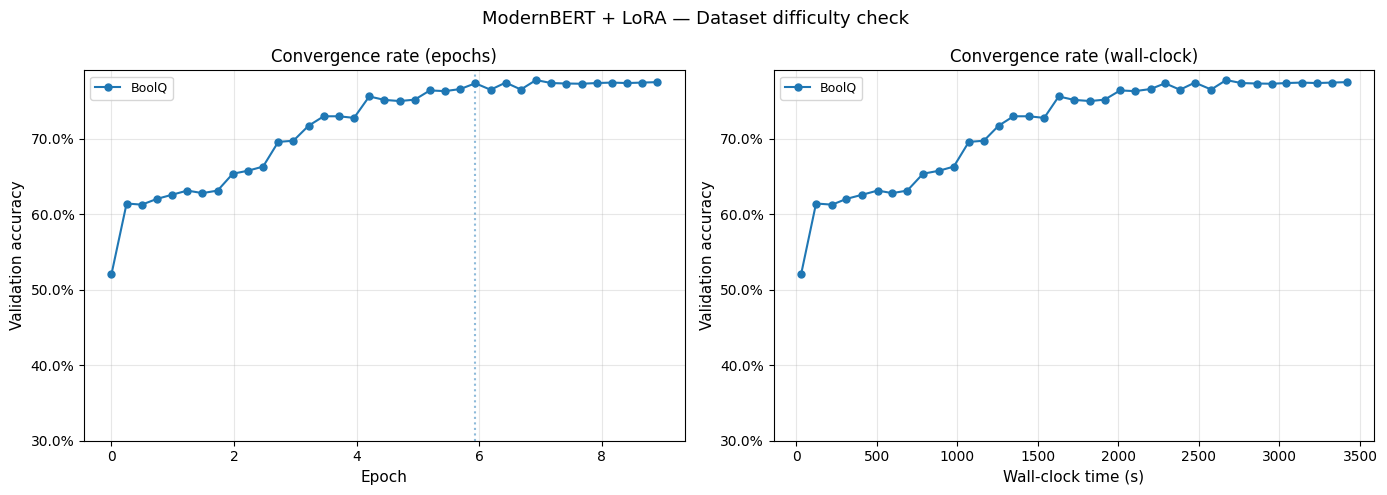


Combined summary saved: preliminary_results/summary_all_tasks.json


In [15]:
results = {}

CURRENT_TASK = "boolq"   # change this each time
OVERRIDES = {
    "qnli":    {"batch_size": 64, "num_epochs": 10},
    "mnli":    {"batch_size": 64, "num_epochs": 10},
    "boolq":   {"batch_size": 32, "num_epochs": 10},   # long sequences need smaller batch
    "medmcqa": {"batch_size": 64, "num_epochs": 10},
}

cfg = TASK_REGISTRY[CURRENT_TASK]
if CURRENT_TASK in OVERRIDES:
    for k, v in OVERRIDES[CURRENT_TASK].items():
        setattr(cfg, k, v)

logger_cb, summary = run_task(cfg)
results[CURRENT_TASK] = (logger_cb, summary)
 
# ── Report ────────────────────────────────────────────────────────────────────
print_table(results)
plot_results(results)


# Save combined summary across all tasks
if SAVE_JSON:
    combined = {
        key: results[key][1]   # summary dict only
        for key in results
    }
    path = JSON_DIR / "summary_all_tasks.json"
    path.write_text(json.dumps(combined, indent=2))
    print(f"\nCombined summary saved: {path}")